### [ 블러링 - 커널과 이미지 밝기 관계 ] <hr>
- 필터링의 핵심요소 => 커널
- 커널을 채운 값에 따라서 => 필터링 방식 다양
- 커널 형태/크기
    * 홀수 - 중심픽셀과 주변 픽셀
    * 짝수 - 동일한 가중치
    * nxn일 필요는 없음 => 상황에 따라 nxm, mxn
- 커널 생성 공식
    * 1/n [ndarray] * 1/n
    * n : ndarray 합계
    * n == ndarray 합계 : 동일 밝기
    * n < ndarray 합계 : 기존 이미지보다 밝아짐
    * n > ndarray 합계 : 기존 이미지보다 어두워짐

In [1]:
import numpy as np, cv2, matplotlib.pyplot as plt, koreanize_matplotlib, sys
sys.path.append(r'C:\Users\Win11Pro\Desktop\KDT-14\[7]_CVISION')
from cv_utils import *

In [ ]:
# 커널 생성 : n에 따른 6개 커널
# => 커널 3x3
# value = np.array(([1,1,1], [1,1,1], [1,1,1]))
value = np.ones((3,3))
ns = [1,2,4,9.13,15]

kernels = [value/n for n in ns]

for k, n in zip(kernels, ns):
    print(f'\n n={n} 커널 ===> \n {k}')


 n=1 커널 ===> 
 [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]

 n=2 커널 ===> 
 [[0.5 0.5 0.5]
 [0.5 0.5 0.5]
 [0.5 0.5 0.5]]

 n=4 커널 ===> 
 [[0.25 0.25 0.25]
 [0.25 0.25 0.25]
 [0.25 0.25 0.25]]

 n=9.13 커널 ===> 
 [[0.10952903 0.10952903 0.10952903]
 [0.10952903 0.10952903 0.10952903]
 [0.10952903 0.10952903 0.10952903]]

 n=15 커널 ===> 
 [[0.06666667 0.06666667 0.06666667]
 [0.06666667 0.06666667 0.06666667]
 [0.06666667 0.06666667 0.06666667]]


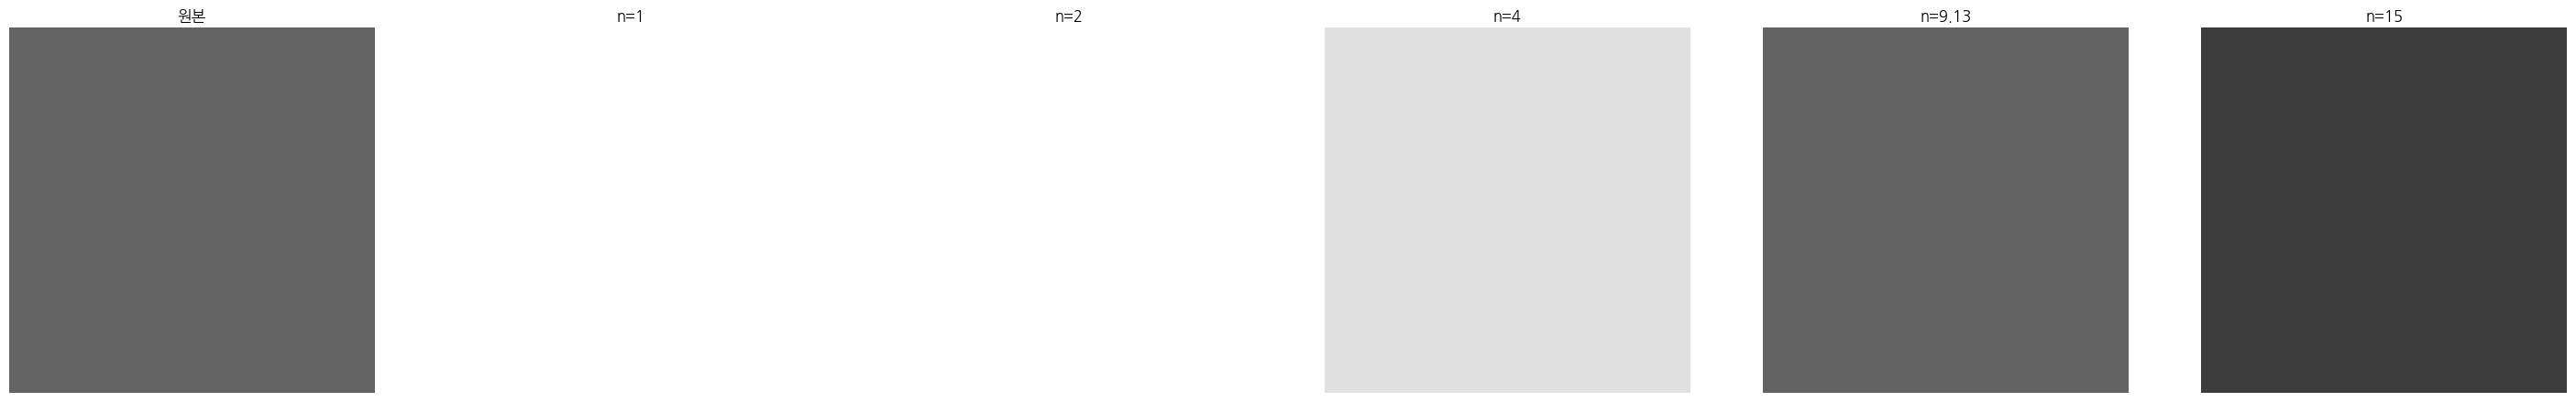

In [ ]:
# 시각화
test = np.ones((7,7,3), dtype=np.uint8)* 100

burs = [cv2.filter2D(test, -1,kernel) for n, kernel in zip(ns, kernels)]
# burs = []
# for n, kernel in zip(ns, kernels):
#     dst = cv2.filter2D(test, -1,kernel)
#     burs.append(dst)
#     print( n, dst.min(), dst.max(), dst[3,3])

cons = [test] + burs
titles = ['원본'] + [f'n={n}' for n in ns]

printPolts(1,6, titles, cons, ['gray'])